In [27]:
# Import all required packages
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os
import random
from collections import Counter
from sklearn.cluster import KMeans
import pandas as pd

In [28]:
# ============================================
# FUNCTIONS
# ============================================

def load_image(path):
    img = Image.open(path)
    img_array = np.array(img)
    if len(img_array.shape) == 3 and img_array.shape[2] == 4:
        img_array = img_array[:, :, :3]
    return img_array

def crop_border(img_array, tolerance=20):
    h, w = img_array.shape[:2]
    corners = [img_array[0,0], img_array[0,w-1], img_array[h-1,0], img_array[h-1,w-1]]
    border_color = np.mean(corners, axis=0).astype(np.uint8)
    
    def is_border(pixel):
        return np.all(np.abs(pixel.astype(int) - border_color.astype(int)) <= tolerance)
    def is_border_line(line, threshold=0.9):
        return sum(1 for p in line if is_border(p)) / len(line) > threshold
    
    top, bottom, left, right = 0, h-1, 0, w-1
    for i in range(h):
        if not is_border_line(img_array[i, :]): top = i; break
    for i in range(h-1, -1, -1):
        if not is_border_line(img_array[i, :]): bottom = i; break
    for j in range(w):
        if not is_border_line(img_array[:, j]): left = j; break
    for j in range(w-1, -1, -1):
        if not is_border_line(img_array[:, j]): right = j; break
    
    return img_array[top:bottom+1, left:right+1], border_color, (top, bottom, left, right)

def kmeans_cluster(img_array, k, border_color, tolerance=20):
    pixels = img_array.reshape(-1, 3)
    def is_border(p):
        return np.all(np.abs(p.astype(int) - border_color.astype(int)) <= tolerance)
    
    non_border_mask = np.array([not is_border(p) for p in pixels])
    non_border_pixels = pixels[non_border_mask]
    
    if len(non_border_pixels) == 0:
        return np.full(len(pixels), -1), np.zeros((k, 3), dtype=np.uint8)
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(non_border_pixels)
    
    labels = np.full(len(pixels), -1)
    labels[non_border_mask] = kmeans.predict(non_border_pixels)
    
    return labels, kmeans.cluster_centers_.astype(np.uint8)

def generate_random_colors(k):
    colors = []
    for i in range(k):
        hue = int(180 * i / k)
        hsv = np.uint8([[[hue, 255, 255]]])
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0][0]
        colors.append(tuple(rgb))
    return colors

def create_clustered_image(shape, labels, random_colors):
    h, w = shape[:2]
    random_img = np.zeros((h*w, 3), dtype=np.uint8)
    for i in range(h*w):
        if labels[i] >= 0:
            random_img[i] = random_colors[labels[i]]
    return random_img.reshape(h, w, 3)

def fill_holes(img, box_sizes=[3, 5, 7, 11, 15]):
    filled = img.copy()
    h, w = img.shape[:2]
    black_mask = np.all(filled <= 10, axis=2)
    positions = list(zip(*np.where(black_mask)))
    cx, cy = h // 2, w // 2
    positions.sort(key=lambda p: (p[0]-cx)**2 + (p[1]-cy)**2)
    
    for i, j in positions:
        for box in box_sizes:
            half = box // 2
            t, b = max(0, i-half), min(h, i+half+1)
            l, r = max(0, j-half), min(w, j+half+1)
            neighborhood = filled[t:b, l:r].reshape(-1, 3)
            non_black = [tuple(p) for p in neighborhood if np.any(p > 10)]
            if non_black:
                filled[i, j] = Counter(non_black).most_common(1)[0][0]
                break
    return filled

def restore_to_original_shape(processed_img, original_shape, crop_bounds):
    top, bottom, left, right = crop_bounds
    h, w = original_shape[:2]
    restored = np.zeros((h, w, 3), dtype=np.uint8)
    restored[top:bottom+1, left:right+1] = processed_img
    return restored

def process_image(input_path, output_path, k=10):
    original = load_image(input_path)
    cropped, border_color, crop_bounds = crop_border(original)
    labels, centers = kmeans_cluster(cropped, k, border_color)
    random_colors = generate_random_colors(k)
    kmeans_rand = create_clustered_image(cropped.shape, labels, random_colors)
    filled = fill_holes(kmeans_rand)
    restored = restore_to_original_shape(filled, original.shape, crop_bounds)
    Image.fromarray(restored).save(output_path)
    return restored

print("Functions loaded!")

Functions loaded!


In [29]:
# ============================================
# BATCH PROCESS - SET K HERE
# ============================================

K = 9   # <-- CHANGE THIS VALUE
RUN_PROCESSING = False  # <-- SET TO True TO REPROCESS

if RUN_PROCESSING:
    input_folder = 'subi'
    output_folder = 'subcolr'
    os.makedirs(output_folder, exist_ok=True)
    
    images = sorted([f for f in os.listdir(input_folder) if f.endswith('.png')], 
                    key=lambda x: int(x.split('.')[0]))
    
    print(f"Processing {len(images)} images with K={K}...")
    for i, img_name in enumerate(images):
        input_path = os.path.join(input_folder, img_name)
        output_path = os.path.join(output_folder, img_name)
        process_image(input_path, output_path, K)
        print(f"[{i+1}/{len(images)}] Processed {img_name}")
    print(f"\nDone! Saved {len(images)} images to {output_folder}/")
else:
    print(f"Processing SKIPPED. Set RUN_PROCESSING = True to reprocess with K={K}")

Processing SKIPPED. Set RUN_PROCESSING = True to reprocess with K=9


Randomly selected images: ['10', '8', '16', '7', '1']



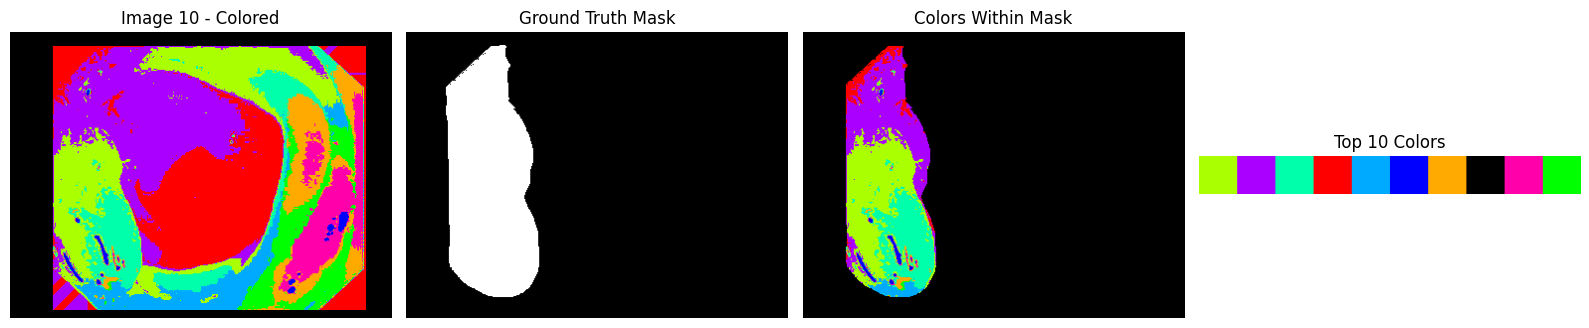


=== Image 10 - Frequency Map (within white mask) ===
Total masked pixels: 18262
Unique colors: 10
          RGB  Frequency  Percentage
(170, 255, 0)       6531       35.76
(170, 0, 255)       5645       30.91
(0, 255, 170)       3790       20.75
  (255, 0, 0)        975        5.34
(0, 170, 255)        535        2.93
  (0, 0, 255)        279        1.53
(255, 170, 0)        250        1.37
    (0, 0, 0)        135        0.74
(255, 0, 170)         83        0.45
  (0, 255, 0)         39        0.21

>>> TOP 3 COLORS COMBINED: 87.42%



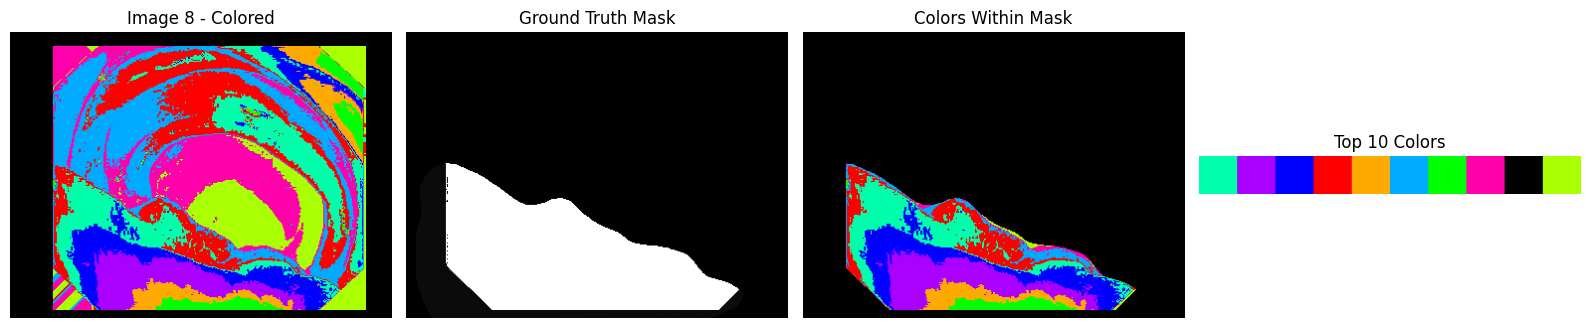


=== Image 8 - Frequency Map (within white mask) ===
Total masked pixels: 24805
Unique colors: 10
          RGB  Frequency  Percentage
(0, 255, 170)       5459       22.01
(170, 0, 255)       5304       21.38
  (0, 0, 255)       5251       21.17
  (255, 0, 0)       3578       14.42
(255, 170, 0)       1851        7.46
(0, 170, 255)       1337        5.39
  (0, 255, 0)       1146        4.62
(255, 0, 170)        374        1.51
    (0, 0, 0)        285        1.15
(170, 255, 0)        220        0.89

>>> TOP 3 COLORS COMBINED: 64.56%



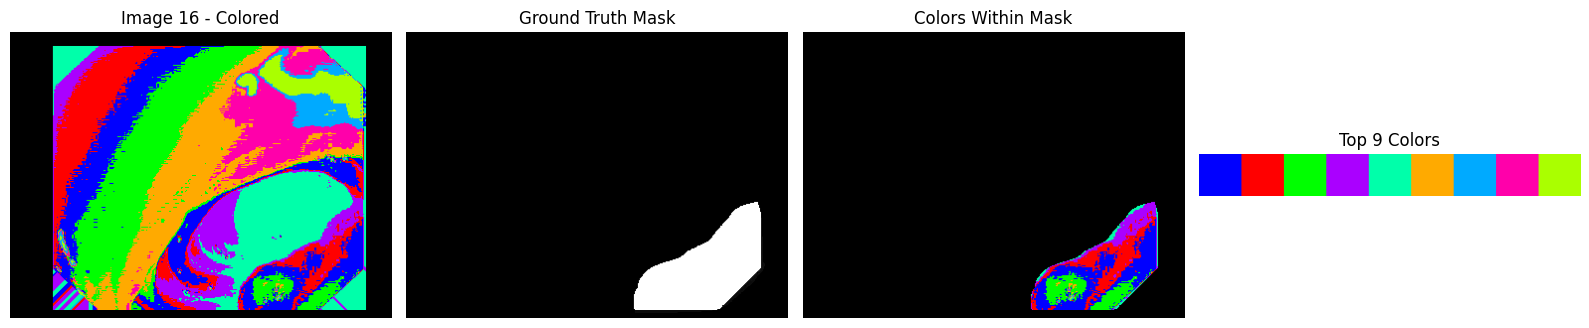


=== Image 16 - Frequency Map (within white mask) ===
Total masked pixels: 7893
Unique colors: 9
          RGB  Frequency  Percentage
  (0, 0, 255)       3034       38.44
  (255, 0, 0)       1946       24.65
  (0, 255, 0)       1426       18.07
(170, 0, 255)       1087       13.77
(0, 255, 170)        307        3.89
(255, 170, 0)         58        0.73
(0, 170, 255)         18        0.23
(255, 0, 170)         11        0.14
(170, 255, 0)          6        0.08

>>> TOP 3 COLORS COMBINED: 81.16%



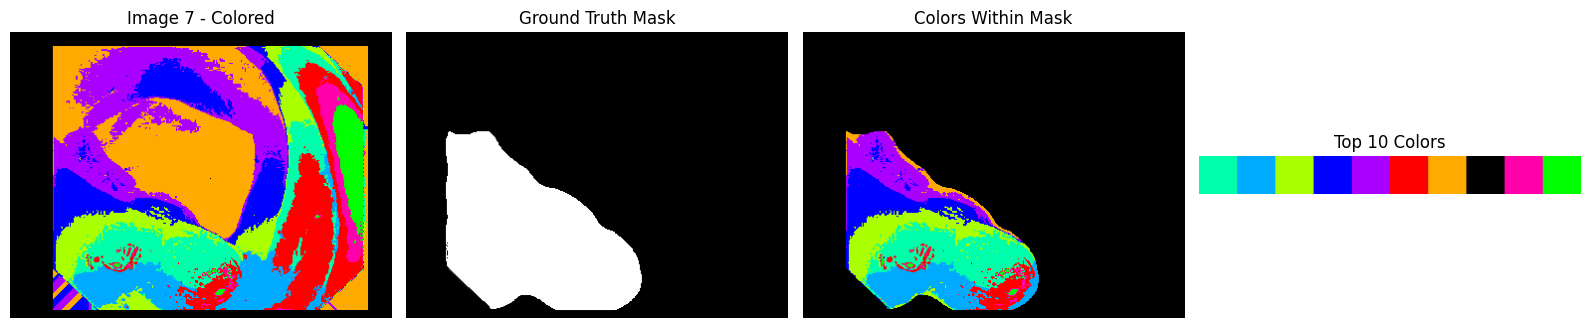


=== Image 7 - Frequency Map (within white mask) ===
Total masked pixels: 23387
Unique colors: 10
          RGB  Frequency  Percentage
(0, 255, 170)       5616       24.01
(0, 170, 255)       3825       16.36
(170, 255, 0)       3766       16.10
  (0, 0, 255)       3754       16.05
(170, 0, 255)       3463       14.81
  (255, 0, 0)       1548        6.62
(255, 170, 0)        712        3.04
    (0, 0, 0)        312        1.33
(255, 0, 170)        267        1.14
  (0, 255, 0)        124        0.53

>>> TOP 3 COLORS COMBINED: 56.47%



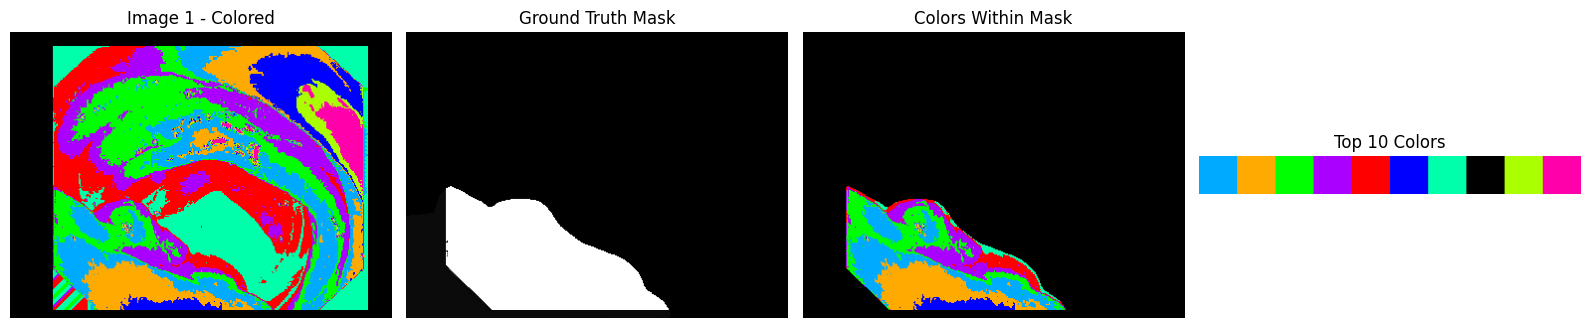


=== Image 1 - Frequency Map (within white mask) ===
Total masked pixels: 16978
Unique colors: 10
          RGB  Frequency  Percentage
(0, 170, 255)       4398       25.90
(255, 170, 0)       3811       22.45
  (0, 255, 0)       3591       21.15
(170, 0, 255)       2440       14.37
  (255, 0, 0)       1127        6.64
  (0, 0, 255)        904        5.32
(0, 255, 170)        447        2.63
    (0, 0, 0)        230        1.35
(170, 255, 0)         22        0.13
(255, 0, 170)          8        0.05

>>> TOP 3 COLORS COMBINED: 69.50%



In [30]:
# ============================================
# FREQUENCY MAP - RANDOM 5 IMAGES
# ============================================

# Get all available images and pick 5 random
all_images = [str(i) for i in range(1, 31)]
image_ids = random.sample(all_images, 5)
print(f"Randomly selected images: {image_ids}\n")

for img_id in image_ids:
    colored = load_image(f'subcolr/{img_id}.png')
    gt = load_image(f'subgt/{img_id}.png')
    
    if len(gt.shape) == 3:
        white_mask = np.all(gt > 200, axis=2)
    else:
        white_mask = gt > 200
    
    masked_pixels = colored[white_mask]
    pixel_tuples = [tuple(p) for p in masked_pixels]
    freq_map = Counter(pixel_tuples)
    
    freq_df = pd.DataFrame(
        [(rgb, count) for rgb, count in freq_map.most_common()],
        columns=['RGB', 'Frequency']
    )
    freq_df['Percentage'] = (freq_df['Frequency'] / len(masked_pixels) * 100).round(2)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(colored)
    axes[0].set_title(f'Image {img_id} - Colored')
    axes[0].axis('off')
    
    axes[1].imshow(gt, cmap='gray')
    axes[1].set_title(f'Ground Truth Mask')
    axes[1].axis('off')
    
    masked_view = np.zeros_like(colored)
    masked_view[white_mask] = colored[white_mask]
    axes[2].imshow(masked_view)
    axes[2].set_title(f'Colors Within Mask')
    axes[2].axis('off')
    
    top_colors = freq_df.head(10)
    color_bar = np.zeros((50, len(top_colors)*50, 3), dtype=np.uint8)
    for i, (rgb, _, _) in enumerate(top_colors.values):
        color_bar[:, i*50:(i+1)*50] = rgb
    axes[3].imshow(color_bar)
    axes[3].set_title(f'Top {len(top_colors)} Colors')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n=== Image {img_id} - Frequency Map (within white mask) ===")
    print(f"Total masked pixels: {len(masked_pixels)}")
    print(f"Unique colors: {len(freq_map)}")
    print(freq_df.head(10).to_string(index=False))
    
    top3_sum = freq_df.head(3)['Percentage'].sum()
    print(f"\n>>> TOP 3 COLORS COMBINED: {top3_sum:.2f}%")
    print()